In [1]:
import kagglehub
from os import getcwd
import shutil

In [2]:
# Download latest version
path = kagglehub.dataset_download("shilongzhuang/telecom-customer-churn-by-maven-analytics")
shutil.copytree(path, getcwd(), dirs_exist_ok=True)
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telecom-customer-churn-by-maven-analytics' dataset.
Path to dataset files: /kaggle/input/telecom-customer-churn-by-maven-analytics


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('telecom_customer_churn.csv')
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [5]:
df.shape

(7043, 38)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [7]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [8]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


Delete the eunnecssary columns

missing value handel

In [9]:
df[df["Churn Category"].isna()]

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
5,0013-MHZWF,Female,23,No,3,Midpines,95345,37.581496,-119.972762,0,...,Credit Card,69.40,571.45,0.00,0,150.93,722.38,Stayed,NaN,NaN
6,0013-SMEOE,Female,67,Yes,0,Lompoc,93437,34.757477,-120.550507,1,...,Bank Withdrawal,109.70,7904.25,0.00,0,707.16,8611.41,Stayed,NaN,NaN
7,0014-BMAQU,Male,52,Yes,0,Napa,94558,38.489789,-122.270110,8,...,Credit Card,84.65,5377.80,0.00,20,816.48,6214.28,Stayed,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,9979-RGMZT,Female,20,No,0,Los Angeles,90022,34.023810,-118.156582,0,...,Credit Card,94.05,633.45,0.00,0,255.43,888.88,Stayed,NaN,NaN
7038,9987-LUTYD,Female,20,No,0,La Mesa,91941,32.759327,-116.997260,0,...,Credit Card,55.15,742.90,0.00,0,606.84,1349.74,Stayed,NaN,NaN
7040,9992-UJOEL,Male,22,No,0,Elk,95432,39.108252,-123.645121,0,...,Credit Card,50.30,92.75,0.00,0,37.24,129.99,Joined,NaN,NaN
7041,9993-LHIEB,Male,21,Yes,0,Solana Beach,92075,33.001813,-117.263628,5,...,Credit Card,67.85,4627.65,0.00,0,142.04,4769.69,Stayed,NaN,NaN


In [10]:
df["City"] = df["City"].str.strip()

city_counts = df["City"].value_counts()

count = df["City"].map(city_counts)

df["City"] = np.select(
    [
        count <= 4,
        count <= 5,
        count <= 10
    ],
    [
        "Other (<=4)",
        "Other (<=5)",
        "Other (6-10)"
    ],
    default=df["City"]
)

In [11]:
df["City"].value_counts()

,count
City,
Other (<=4),3236
Other (6-10),668
Other (<=5),640
Los Angeles,293
San Diego,285
...,...
San Leandro,12
Fontana,12
Santa Maria,12


In [12]:
df["Churn Category"].value_counts()

,count
Churn Category,
Competitor,841
Dissatisfaction,321
Attitude,314
Price,211
Other,182


In [13]:
df[(df["Customer Status"] == "Churned")]

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
2,0004-TLHLJ,Male,50,No,0,Other (6-10),92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.90,280.85,0.0,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Other (<=4),94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.00,1237.85,0.0,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Other (6-10),93010,34.227846,-119.079903,3,...,Credit Card,83.90,267.40,0.0,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
18,0022-TCJCI,Male,79,No,0,Other (6-10),94015,37.680844,-122.481310,0,...,Credit Card,62.70,2791.50,0.0,0,480.15,3271.65,Churned,Dissatisfaction,Limited range of services
19,0023-HGHWL,Male,67,No,0,Other (<=4),95037,37.161544,-121.649371,0,...,Bank Withdrawal,25.10,25.10,0.0,0,0.00,25.10,Churned,Competitor,Competitor made better offer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7020,9961-JBNMK,Male,79,No,0,Other (<=5),92239,33.889605,-115.257009,0,...,Bank Withdrawal,-1.00,2030.30,10.2,0,887.67,2907.77,Churned,Dissatisfaction,Product dissatisfaction
7023,9965-YOKZB,Male,73,No,0,Other (<=4),95636,38.636102,-120.522149,0,...,Bank Withdrawal,83.85,790.15,0.0,0,90.36,880.51,Churned,Dissatisfaction,Network reliability
7036,9985-MWVIX,Female,53,No,0,Other (<=4),93628,36.807595,-118.901544,0,...,Credit Card,70.15,70.15,0.0,0,42.09,112.24,Churned,Competitor,Competitor had better devices
7037,9986-BONCE,Female,36,No,0,Fallbrook,92028,33.362575,-117.299644,0,...,Bank Withdrawal,20.95,85.50,0.0,0,8.04,93.54,Churned,Competitor,Competitor made better offer


Text Cells Are Replaced by Text objects and rest are filled by 0

In [14]:
df['Offer'] = df['Offer'].fillna('No Offer')

In [15]:
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)
df['Multiple Lines'] = df['Multiple Lines'].fillna('No')

In [16]:
internet_cols = [
    'Internet Type',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data'
]

for col in internet_cols:
    df[col] = df[col].fillna('No Internet')

df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)

In [17]:
# df['Churn Category'] = df['Churn Category'].fillna('Retained')

In [18]:
df.drop(columns=['Customer ID', 'Zip Code', 'Latitude', 'Longitude', 'Churn Reason', "Online Security", "Online Backup","Device Protection Plan","Premium Tech Support","Streaming TV","Streaming Movies","Streaming Music","Unlimited Data","Churn Category"], inplace=True, errors='ignore')

In [19]:
df.head()

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,Female,37,Yes,0,Other (6-10),2,9,No Offer,Yes,42.39,...,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed
1,Male,46,No,0,Glendale,0,9,No Offer,Yes,10.69,...,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed
2,Male,50,No,0,Other (6-10),0,4,Offer E,Yes,33.65,...,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned
3,Male,78,Yes,0,Other (<=4),1,13,Offer D,Yes,27.82,...,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned
4,Female,75,Yes,0,Other (6-10),3,3,No Offer,Yes,7.38,...,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   object 
 1   Age                                7043 non-null   int64  
 2   Married                            7043 non-null   object 
 3   Number of Dependents               7043 non-null   int64  
 4   City                               7043 non-null   object 
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Offer                              7043 non-null   object 
 8   Phone Service                      7043 non-null   object 
 9   Avg Monthly Long Distance Charges  7043 non-null   float64
 10  Multiple Lines                     7043 non-null   object 
 11  Internet Service                   7043 non-null   objec

In [21]:
df.isnull().sum()

,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Number of Referrals,0
Tenure in Months,0
Offer,0
Phone Service,0
Avg Monthly Long Distance Charges,0


In [22]:
df.describe()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,1.951867,32.386767,22.958954,20.515405,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,3.001199,24.542061,15.448113,20.418940,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,0.000000,9.000000,9.210000,3.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,0.000000,29.000000,22.890000,17.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,3.000000,55.000000,36.395000,27.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


{'whiskers': [<matplotlib.lines.Line2D at 0x7e7768876a80>,
 'caps': [<matplotlib.lines.Line2D at 0x7e77688770b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e776915ede0>],
 'medians': [<matplotlib.lines.Line2D at 0x7e7768877710>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e7768877a40>],
 'means': []}

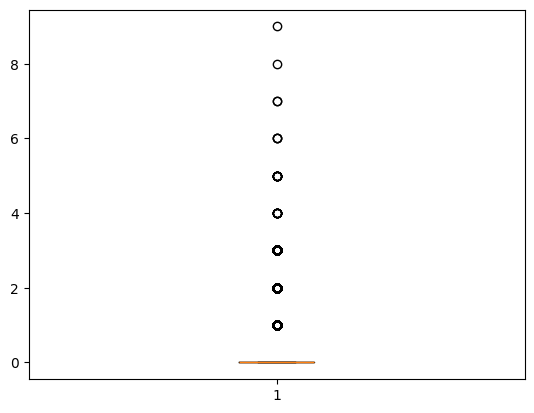

In [23]:
plt.boxplot(df['Number of Dependents'])

In [24]:
low, high = df['Number of Dependents'].quantile([0.1, 0.95])

In [25]:
print(low,high)

0.0 3.0


In [26]:
df[df['Number of Dependents'] > 3].to_csv("Number_of_Dependents.csv")

{'whiskers': [<matplotlib.lines.Line2D at 0x7e7768725010>,
 'caps': [<matplotlib.lines.Line2D at 0x7e77687256a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e7768724c80>],
 'medians': [<matplotlib.lines.Line2D at 0x7e7768725d00>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e7768726030>],
 'means': []}

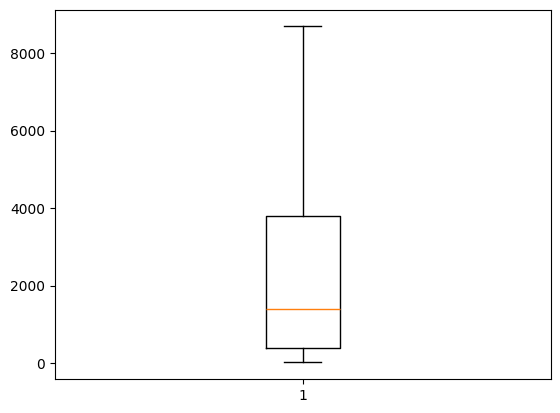

In [27]:
plt.boxplot(df['Total Charges'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7e776876a150>,
 'caps': [<matplotlib.lines.Line2D at 0x7e776876a600>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e7768769e80>],
 'medians': [<matplotlib.lines.Line2D at 0x7e776876ac00>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e776876af00>],
 'means': []}

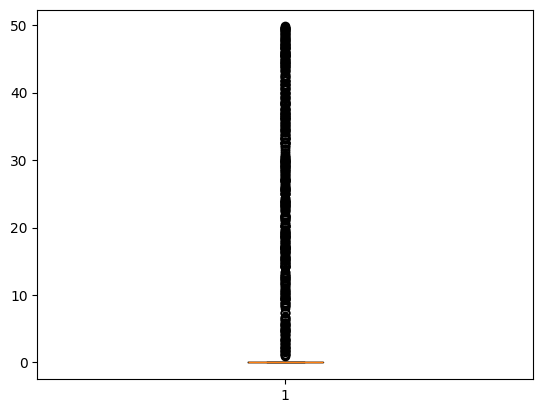

In [28]:
plt.boxplot(df['Total Refunds'])

In [29]:
low, high = df['Total Refunds'].quantile([0.1, 0.95])

In [30]:
print(low,high)

0.0 18.148999999999926


In [31]:
df[df['Total Refunds'] > 18].to_csv("Total_Refunds.csv")

In [32]:
print(low,high)

0.0 18.148999999999926


{'whiskers': [<matplotlib.lines.Line2D at 0x7e77687b3e00>,
 'caps': [<matplotlib.lines.Line2D at 0x7e77687b3800>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e77687b0980>],
 'medians': [<matplotlib.lines.Line2D at 0x7e77687b3230>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e776873e840>],
 'means': []}

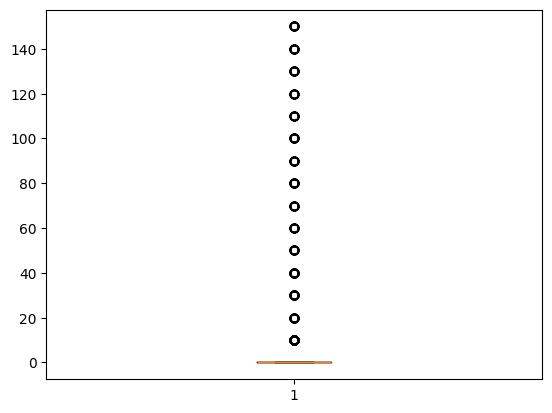

In [33]:
plt.boxplot(df['Total Extra Data Charges'])

In [34]:
low, high = df['Total Extra Data Charges'].quantile([0.1, 0.95])
print(low,high)

0.0 60.0


In [35]:
df[df['Total Extra Data Charges'] > 60].to_csv("Total_Extra_Data_Charges.csv")

{'whiskers': [<matplotlib.lines.Line2D at 0x7e7768648e60>,
 'caps': [<matplotlib.lines.Line2D at 0x7e776864b4a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e7768878230>],
 'medians': [<matplotlib.lines.Line2D at 0x7e776864a3f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e77686491c0>],
 'means': []}

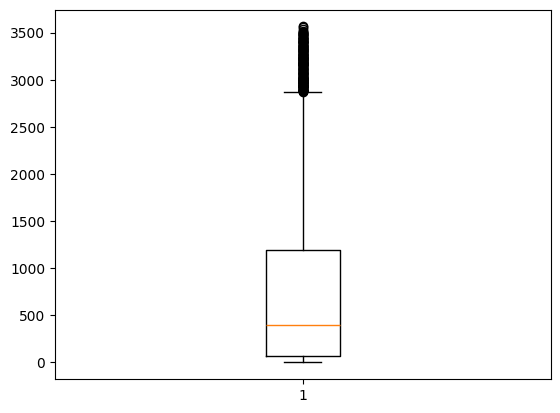

In [36]:
plt.boxplot(df['Total Long Distance Charges'])

In [37]:
low, high = df['Total Long Distance Charges'].quantile([0.1, 0.95])
print(low,high)

3.1320000000000006 2577.877


In [38]:
df[df['Total Long Distance Charges'] > 2577].to_csv("Total_Long_Distance_Charges.csv")

EDA

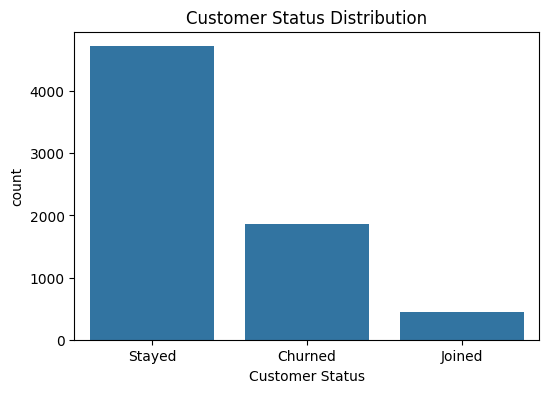

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x='Customer Status', data=df)
plt.title("Customer Status Distribution")
plt.show()

print(df['Customer Status'].value_counts())

In [40]:
df['Customer Status'] = df['Customer Status'].map({'Stayed': 0,'Churned': 1,'Joined':0})

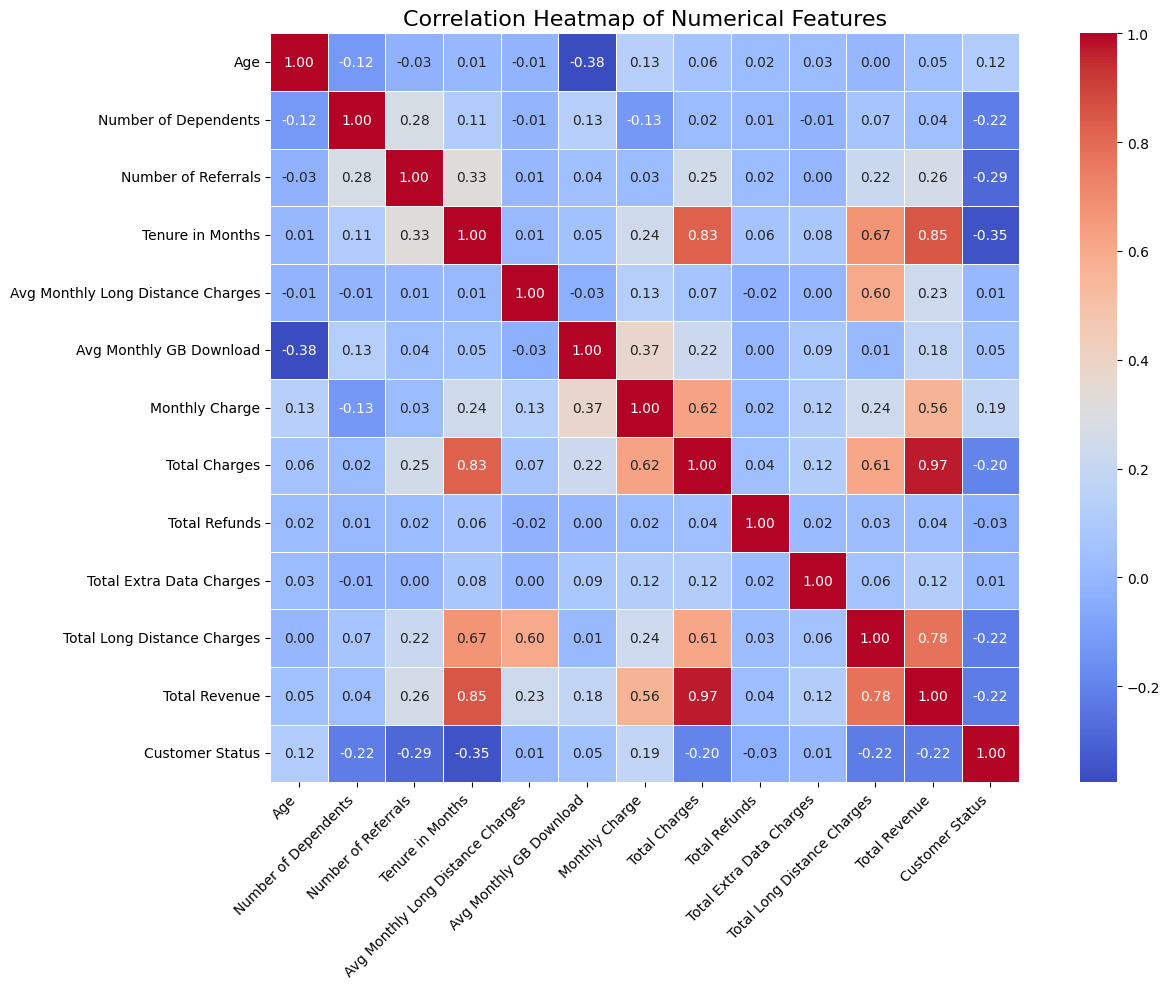

In [41]:
# Calculate correlation matrix
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

# Plot
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [42]:
df.drop(columns=["Total Revenue","Total Long Distance Charges","Total Charges"], inplace=True)

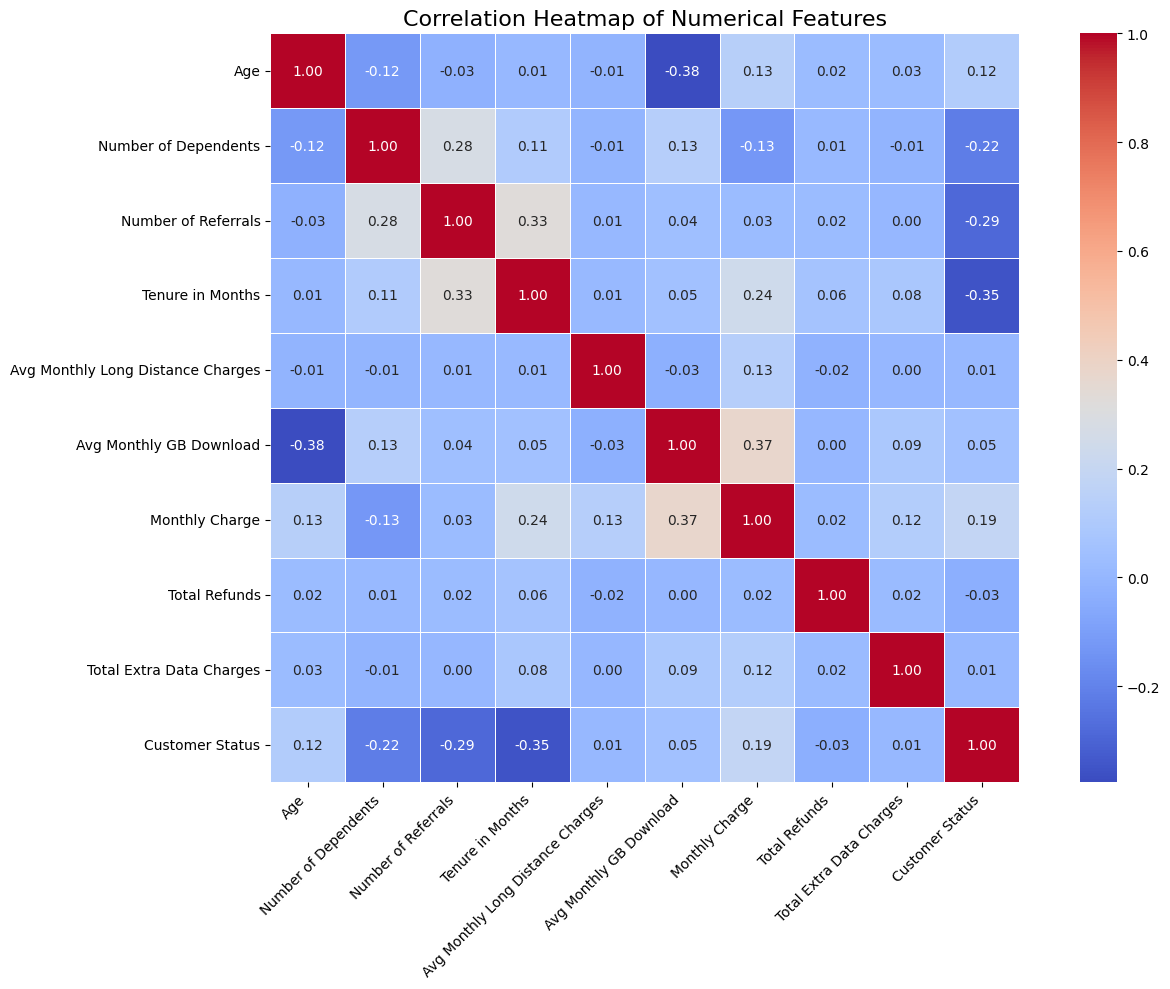

In [43]:
# Calculate correlation matrix
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

# Plot
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Convert Target Variable


In [44]:
# df = df[df['Customer Status'] != 'Joined']

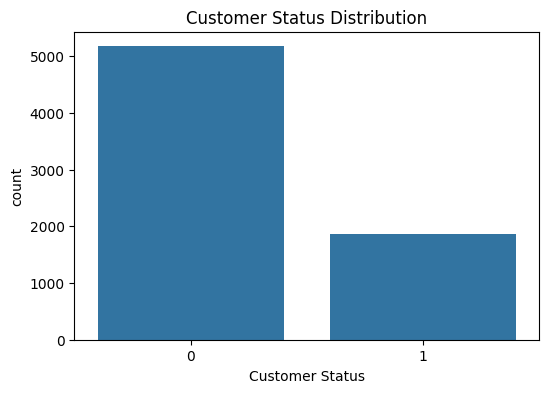

Customer Status
0    5174
1    1869
Name: count, dtype: int64


In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='Customer Status', data=df)
plt.title("Customer Status Distribution")
plt.show()

print(df['Customer Status'].value_counts())

Separate Features and Target

In [46]:
X = df.drop('Customer Status', axis=1)
y = df['Customer Status']

In [47]:
print(X.shape)
print(y.shape)

(7043, 20)
(7043,)


Identify Categorical and Numerical Features

In [48]:
# categorical_cols = X.select_dtypes(include='object').columns.tolist()
# numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# print("Categorical Columns:")
# print(categorical_cols)

# print("\nNumerical Columns:")
# print(numerical_cols)

One-Hot Encode Categorical Features

In [49]:
# print(X.columns.tolist())

In [50]:
print(X.shape)
print(X.head())

(7043, 20)
   Gender  Age Married  Number of Dependents          City  \
0  Female   37     Yes                     0  Other (6-10)   
1    Male   46      No                     0      Glendale   
2    Male   50      No                     0  Other (6-10)   
3    Male   78     Yes                     0   Other (<=4)   
4  Female   75     Yes                     0  Other (6-10)   

   Number of Referrals  Tenure in Months     Offer Phone Service  \
0                    2                 9  No Offer           Yes   
1                    0                 9  No Offer           Yes   
2                    0                 4   Offer E           Yes   
3                    1                13   Offer D           Yes   
4                    3                 3  No Offer           Yes   

   Avg Monthly Long Distance Charges Multiple Lines Internet Service  \
0                              42.39             No              Yes   
1                              10.69            Yes            

Continue with Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    # stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6338, 20)
(705, 20)


the catogry colum eas not endcoded first encode it

In [53]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [54]:
numerical_columns = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = X_train.select_dtypes(include='object').columns.tolist()

In [55]:
# model = make_pipeline(StandardScaler(), OneHotEncoder(), LogisticRegression())

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

In [57]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Number of Dependents',
                                                   'Number of Referrals',
                                                   'Tenure in Months',
                                                   'Avg Monthly Long Distance '
                                                   'Charges',
                                                   'Avg Monthly GB Download',
                                                   'Monthly Charge',
                                                   'Total Refunds',
                                                   'Total Extra Data Charges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Married', 'City',
                                                   'Offer', 'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Internet Type', 'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier', LogisticRegression())])

In [58]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
print(mae)

0.16595744680851063


In [59]:
model.score(X_test, y_test)

0.8340425531914893